In [1]:
%matplotlib inline
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
from skimage.metrics import structural_similarity, mean_squared_error

In [2]:
# 1. Загрузка
image = cv2.imread('oh.jpg', cv2.IMREAD_GRAYSCALE)
print(image.shape, image.dtype)

(500, 1000) uint8


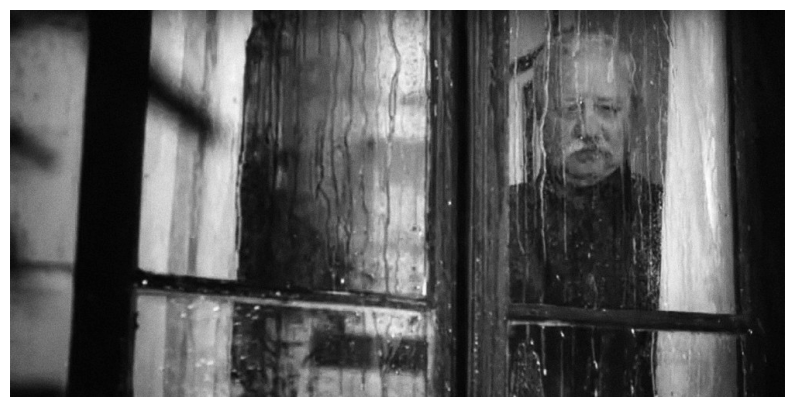

In [3]:
plt.figure(figsize=(10, 6))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [4]:
# 2. Зашумление

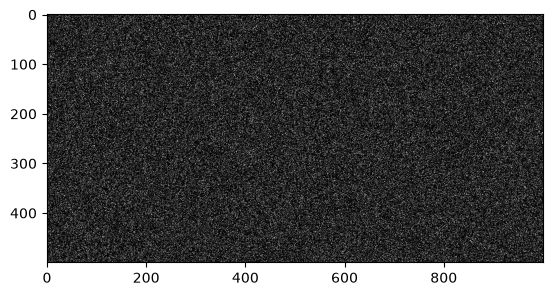

In [5]:
# гауссов шум
mean = 0
stddev = 100
noise_gauss = np.zeros(image.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image, noise_gauss)
plt.imshow(noise_gauss, cmap="gray")

In [6]:
# "соль и перец"
noise = np.random.randint(0, 101, size=image.shape, dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

image_sp = copy.deepcopy(image)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

In [7]:
# метрики
def evaluate(original, filtered, name):
    mse = mean_squared_error(original, filtered)
    ssim = structural_similarity(original, filtered, full=True)[0]
    return {"name": name, "MSE": mse, "SSIM": ssim}

baseline_results = [
    evaluate(image, image_noise_gauss, "Gauss noise"),
    evaluate(image, image_sp,        "Salt & Pepper noise"),
]

for r in baseline_results:
    print(f"{r['name']:20s}  MSE = {r['MSE']:.2f}   SSIM = {r['SSIM']:.4f}")

Gauss noise           MSE = 3418.40   SSIM = 0.1219
Salt & Pepper noise   MSE = 384.36   SSIM = 0.5930


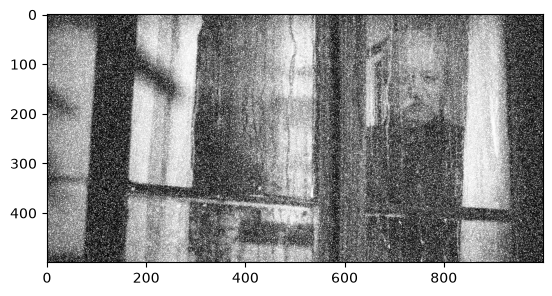

In [8]:
plt.imshow(image_noise_gauss, cmap="gray")

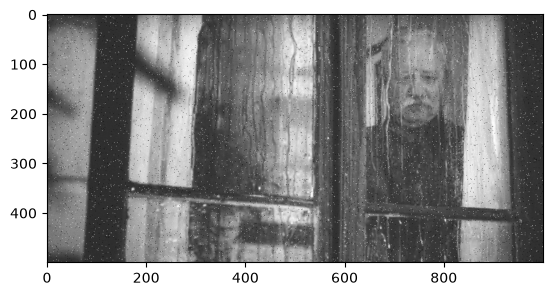

In [9]:
plt.imshow(image_sp, cmap="gray")

In [10]:
# 3. Фильтрация
results = []

In [11]:
# 1) медианный
for ksize in [3, 5, 7]:
    img_g = cv2.medianBlur(image_noise_gauss, ksize)
    img_s = cv2.medianBlur(image_sp, ksize)
    r_g = evaluate(image, img_g, 'медианный')
    r_s = evaluate(image, img_s, 'медианный')
    print(f"k={ksize}: gauss MSE={r_g['MSE']:.2f} SSIM={r_g['SSIM']:.4f} | "
          f"sp MSE={r_s['MSE']:.2f} SSIM={r_s['SSIM']:.4f}")
    r_g.update({"noise": "gauss", "ksize": ksize})
    results.append(r_g)
    r_s.update({"noise": "sp", "ksize": ksize})
    results.append(r_s)

k=3: gauss MSE=827.44 SSIM=0.3147 | sp MSE=12.37 SSIM=0.9298
k=5: gauss MSE=412.80 SSIM=0.5090 | sp MSE=26.82 SSIM=0.8821
k=7: gauss MSE=337.21 SSIM=0.5920 | sp MSE=48.03 SSIM=0.8239


In [12]:
# 2) гаусса
for ksize in [(3, 3), (5, 5), (7, 7)]:
    for sigma in [0, 1, 2]:
        img_g = cv2.GaussianBlur(image_noise_gauss, ksize, sigma)
        img_s = cv2.GaussianBlur(image_sp, ksize, sigma)
        r_g = evaluate(image, img_g, 'гаусса')
        r_s = evaluate(image, img_s, 'гаусса')
        print(f"Гаусса ksize={ksize} sigma={sigma}:  gauss MSE={r_g['MSE']:.2f} SSIM={r_g['SSIM']:.4f}  |  "
              f"sp MSE={r_s['MSE']:.2f} SSIM={r_s['SSIM']:.4f}")
        r_g.update({"noise": "gauss", "ksize": ksize, "sigma": sigma})
        results.append(r_g)
        r_s.update({"noise": "sp", "ksize": ksize, "sigma": sigma})
        results.append(r_s)

Гаусса ksize=(3, 3) sigma=0:  gauss MSE=1526.99 SSIM=0.3700  |  sp MSE=64.92 SSIM=0.7578
Гаусса ksize=(3, 3) sigma=1:  gauss MSE=1493.87 SSIM=0.3875  |  sp MSE=60.76 SSIM=0.7629
Гаусса ksize=(3, 3) sigma=2:  gauss MSE=1465.90 SSIM=0.4018  |  sp MSE=58.48 SSIM=0.7613
Гаусса ksize=(5, 5) sigma=0:  gauss MSE=1386.97 SSIM=0.4764  |  sp MSE=46.99 SSIM=0.7993
Гаусса ksize=(5, 5) sigma=1:  gauss MSE=1403.81 SSIM=0.4584  |  sp MSE=48.61 SSIM=0.7948
Гаусса ksize=(5, 5) sigma=2:  gauss MSE=1329.30 SSIM=0.5578  |  sp MSE=46.76 SSIM=0.8082
Гаусса ksize=(7, 7) sigma=0:  gauss MSE=1322.69 SSIM=0.5736  |  sp MSE=45.12 SSIM=0.8178
Гаусса ksize=(7, 7) sigma=1:  gauss MSE=1396.65 SSIM=0.4655  |  sp MSE=47.91 SSIM=0.7971
Гаусса ksize=(7, 7) sigma=2:  gauss MSE=1305.08 SSIM=0.6204  |  sp MSE=52.01 SSIM=0.8094


In [13]:
# 3) билатеральный
for d in [5, 9, 15]:
    for sigma_color in [50, 75, 100]:
        for sigma_space in [50, 75, 100]:
            img_g = cv2.bilateralFilter(image_noise_gauss, d, sigma_color, sigma_space)
            img_s = cv2.bilateralFilter(image_sp, d, sigma_color, sigma_space)
            r_g = evaluate(image, img_g, 'билатеральный')
            r_s = evaluate(image, img_s, 'билатеральный')
            print(f"Билатеральный d={d} σс={sigma_color} σs={sigma_space}:  "
                  f"gauss MSE={r_g['MSE']:.2f} SSIM={r_g['SSIM']:.4f}  |  "
                  f"sp MSE={r_s['MSE']:.2f} SSIM={r_s['SSIM']:.4f}")
            r_g.update({"noise": "gauss", "d": d, "sigmaColor": sigma_color, "sigmaSpace": sigma_space})
            results.append(r_g)
            r_s.update({"noise": "sp", "d": d, "sigmaColor": sigma_color, "sigmaSpace": sigma_space})
            results.append(r_s)

Билатеральный d=5 σс=50 σs=50:  gauss MSE=2180.81 SSIM=0.2239  |  sp MSE=317.35 SSIM=0.6219
Билатеральный d=5 σс=50 σs=75:  gauss MSE=2180.74 SSIM=0.2239  |  sp MSE=317.34 SSIM=0.6219
Билатеральный d=5 σс=50 σs=100:  gauss MSE=2180.72 SSIM=0.2239  |  sp MSE=317.34 SSIM=0.6219
Билатеральный d=5 σс=75 σs=50:  gauss MSE=1551.67 SSIM=0.3117  |  sp MSE=159.08 SSIM=0.6997
Билатеральный d=5 σс=75 σs=75:  gauss MSE=1551.61 SSIM=0.3117  |  sp MSE=159.07 SSIM=0.6997
Билатеральный d=5 σс=75 σs=100:  gauss MSE=1551.60 SSIM=0.3117  |  sp MSE=159.06 SSIM=0.6997
Билатеральный d=5 σс=100 σs=50:  gauss MSE=1324.56 SSIM=0.3798  |  sp MSE=65.06 SSIM=0.7699
Билатеральный d=5 σс=100 σs=75:  gauss MSE=1324.52 SSIM=0.3798  |  sp MSE=65.05 SSIM=0.7700
Билатеральный d=5 σс=100 σs=100:  gauss MSE=1324.51 SSIM=0.3798  |  sp MSE=65.05 SSIM=0.7700
Билатеральный d=9 σс=50 σs=50:  gauss MSE=2005.54 SSIM=0.2330  |  sp MSE=292.39 SSIM=0.5960
Билатеральный d=9 σс=50 σs=75:  gauss MSE=2005.47 SSIM=0.2330  |  sp MSE=292.

In [14]:
# 4) нелокальных средних
for h in [5, 10, 20, 30]:
    for tw in [5, 7]:
        for sw in [15, 21]:
            img_g = cv2.fastNlMeansDenoising(image_noise_gauss, h=h, templateWindowSize=tw, searchWindowSize=sw)
            img_s = cv2.fastNlMeansDenoising(image_sp, h=h, templateWindowSize=tw, searchWindowSize=sw)
            r_g = evaluate(image, img_g, 'нелокальных средних')
            r_s = evaluate(image, img_s, 'нелокальных средних')
            print(f"Нелокальных средних h={h} tw={tw} sw={sw}:  "
                  f"gauss MSE={r_g['MSE']:.2f} SSIM={r_g['SSIM']:.4f}  |  "
                  f"sp MSE={r_s['MSE']:.2f} SSIM={r_s['SSIM']:.4f}")
            r_g.update({"noise": "gauss", "h": h, "tw": tw, "sw": sw})
            results.append(r_g)
            r_s.update({"noise": "sp", "h": h, "tw": tw, "sw": sw})
            results.append(r_s)

Нелокальных средних h=5 tw=5 sw=15:  gauss MSE=3418.32 SSIM=0.1222  |  sp MSE=387.00 SSIM=0.5721
Нелокальных средних h=5 tw=5 sw=21:  gauss MSE=3418.30 SSIM=0.1223  |  sp MSE=387.22 SSIM=0.5709
Нелокальных средних h=5 tw=7 sw=15:  gauss MSE=3418.35 SSIM=0.1221  |  sp MSE=384.04 SSIM=0.5869
Нелокальных средних h=5 tw=7 sw=21:  gauss MSE=3418.34 SSIM=0.1222  |  sp MSE=383.79 SSIM=0.5872
Нелокальных средних h=10 tw=5 sw=15:  gauss MSE=3411.35 SSIM=0.1319  |  sp MSE=372.94 SSIM=0.5821
Нелокальных средних h=10 tw=5 sw=21:  gauss MSE=3409.89 SSIM=0.1340  |  sp MSE=371.52 SSIM=0.5819
Нелокальных средних h=10 tw=7 sw=15:  gauss MSE=3412.73 SSIM=0.1310  |  sp MSE=360.62 SSIM=0.5986
Нелокальных средних h=10 tw=7 sw=21:  gauss MSE=3411.72 SSIM=0.1329  |  sp MSE=356.27 SSIM=0.5993
Нелокальных средних h=20 tw=5 sw=15:  gauss MSE=3257.34 SSIM=0.1800  |  sp MSE=149.43 SSIM=0.6698
Нелокальных средних h=20 tw=5 sw=21:  gauss MSE=3213.05 SSIM=0.1872  |  sp MSE=135.09 SSIM=0.6793
Нелокальных средних h=20

In [15]:
# 4. Сбор результатов
import pandas as pd

df = pd.DataFrame(results)
df = df[["name", "noise", "MSE", "SSIM", "ksize", "sigma",
         "d", "sigmaColor", "sigmaSpace", "h", "tw", "sw"]]
df

,name,noise,MSE,SSIM,ksize,sigma,d,sigmaColor,sigmaSpace,h,tw,sw
0,медианный,gauss,827.438840,0.314676,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,медианный,sp,12.372276,0.929772,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,медианный,gauss,412.797330,0.508989,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,медианный,sp,26.816044,0.882147,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,медианный,gauss,337.213270,0.591975,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
105,нелокальных средних,sp,69.370706,0.746114,NaN,NaN,NaN,NaN,NaN,30.0,5.0,21.0
106,нелокальных средних,gauss,2224.682278,0.293653,NaN,NaN,NaN,NaN,NaN,30.0,7.0,15.0
107,нелокальных средних,sp,67.553806,0.744102,NaN,NaN,NaN,NaN,NaN,30.0,7.0,15.0
108,нелокальных средних,gauss,1987.576290,0.323752,NaN,NaN,NaN,NaN,NaN,30.0,7.0,21.0


In [16]:
# 5. Вывод
best_ssim = (df.sort_values("SSIM", ascending=False)
               .groupby("noise", as_index=False)
               .head(1))

best_mse = (df.sort_values("MSE", ascending=True)
              .groupby("noise", as_index=False)
              .head(1))

print("Топ-1 по SSIM")
print(best_ssim[["noise", "name", "MSE", "SSIM",
                 "ksize", "sigma", "d", "sigmaColor", "sigmaSpace", "h", "tw", "sw"]]
      .to_string(index=False))

print("\nТоп-1 по MSE")
print(best_mse[["noise", "name", "MSE", "SSIM",
                "ksize", "sigma", "d", "sigmaColor", "sigmaSpace", "h", "tw", "sw"]]
      .to_string(index=False))

Топ-1 по SSIM
noise      name         MSE     SSIM  ksize  sigma   d  sigmaColor  sigmaSpace   h  tw  sw
   sp медианный   12.372276 0.929772      3    NaN NaN         NaN         NaN NaN NaN NaN
gauss    гаусса 1305.076524 0.620354 (7, 7)    2.0 NaN         NaN         NaN NaN NaN NaN

Топ-1 по MSE
noise      name        MSE     SSIM ksize  sigma   d  sigmaColor  sigmaSpace   h  tw  sw
   sp медианный  12.372276 0.929772     3    NaN NaN         NaN         NaN NaN NaN NaN
gauss медианный 337.213270 0.591975     7    NaN NaN         NaN         NaN NaN NaN NaN
